<a href="https://colab.research.google.com/github/jfaraudo/Monte_Carlo_Metropolis_Examples/blob/master/TwoStateModel/two_states_several_T.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MONTECARLO SIMULATION OF A TWO STATE MODEL FOR DIFFERENT TEMPERATURES**

The system is made by a bidimensional array (NxN) of atoms with *only two possible states *labelled with the variable "s".

- The state with s=-1 has zero energy
- The state with s=+1 has energy ϵ

The energy is calculated in units of \epsilon. The model has only one variable which is kT/ϵ .

The code performs an exploration of different values for the temperature T.

In [2]:
# Here we import the numpy mathematical library and the plots library
# as in the other examples in the course
#
import numpy as np
from numpy.random import rand
import matplotlib.pyplot as plt

**FUNCTIONS EMPLOYED IN THE MAIN CODE**

In [5]:
#Generation of a random initial state for NxN sites with 2 states
def initialstate(N):
    ''' generates a random spin configuration for initial condition'''
    state = 2*np.random.randint(2, size=(N,N))-1
    return state

In [6]:
# Function implementing the method (Metropolis Monte Carlo) and model
#      The state with s=-1 has zero energy
#      The state with s=+1 has energy 1
def mcmove(config, beta):
    '''Monte Carlo move using Metropolis algorithm '''
    for i in range(N):
        for j in range(N):
                #select random state from NxN system
                a = np.random.randint(0, N)
                b = np.random.randint(0, N)
                s =  config[a, b]
                #calculate energy cost of fliping current state
                if (s<0):
                   #cost of exciting the system
                   cost=1.0
                else:
                   #cost of decay
                   cost=-1.0
                #flip spin or not depending on the cost and its Boltzmann factor
                ## (acceptance probability is given by Boltzmann factor with beta = 1/kBT
                if cost < 0:
                    s *= -1
                elif rand() < np.exp(-cost*beta):
                    s *= -1
                config[a, b] = s
    return config


In [7]:
#This function calculates the energy of a given configuration for the plots of Energy as a function of T
def calcEnergy(config):
    '''Energy of a given configuration'''
    energy = 0
    for i in range(len(config)):
        for j in range(len(config)):
            State = config[i,j]
            if (State>0):
               energy = energy + 1.0
    return energy


In [8]:
#This function calculates the magnetization of a given configuration
def calcMag(config):
    '''Magnetization of a given configuration'''
    mag = np.sum(config)
    return mag

**Main code:** explore many T. The results are plotted at the end of the full calculation

Starting Simulations at  95  different temperatures.
Simulation  1  of 95  at reduced temperature T= 0.32254266383176167
Simulation  2  of 95  at reduced temperature T= 0.3905137659114295
Simulation  3  of 95  at reduced temperature T= 1.2976408663581602
Simulation  4  of 95  at reduced temperature T= 0.8122033688345184
Simulation  5  of 95  at reduced temperature T= 0.9242628672393618
Simulation  6  of 95  at reduced temperature T= 1.4389425454224463
Simulation  7  of 95  at reduced temperature T= 0.9219958449696695
Simulation  8  of 95  at reduced temperature T= 0.48806562030377254
Simulation  9  of 95  at reduced temperature T= 1.508165074118914
Simulation  10  of 95  at reduced temperature T= 1.2543495221835137
Simulation  11  of 95  at reduced temperature T= 1.4000979685230646
Simulation  12  of 95  at reduced temperature T= 1.219498264399824
Simulation  13  of 95  at reduced temperature T= 0.30592152215863777
Simulation  14  of 95  at reduced temperature T= 1.6870081508114223
Sim

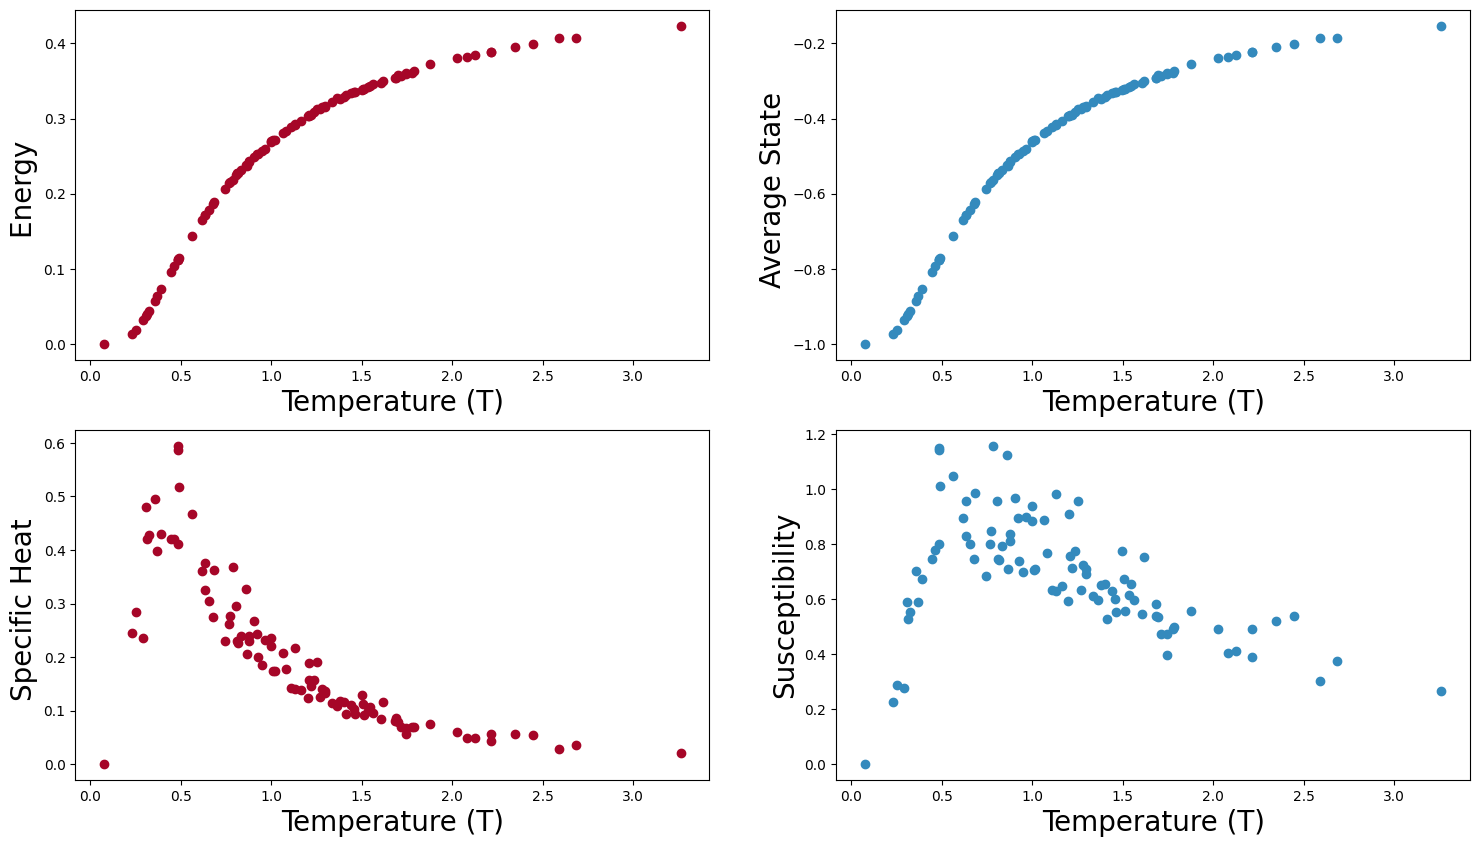

In [9]:
#
# MAIN PROGRAM
#
# Initial parameters for calculation
## change the parameter below if you want to simulate a smaller system
nt      = 100        # number of temperature points
N       = 64        # size of the lattice, N x N
eqSteps = 50       # number of MC sweeps for equilibration
mcSteps = 100       # number of MC sweeps for calculation

n1, n2  = 1.0/(mcSteps*N*N), 1.0/(mcSteps*mcSteps*N*N)
#Generate a random distribution of temperatures to make an exploration
tm = 1.0;    T=np.random.normal(tm, .64, nt)
T  = T[(T>0.0) & (T<5.8)];    nt = np.size(T)

Energy       = np.zeros(nt);   Magnetization  = np.zeros(nt)
SpecificHeat = np.zeros(nt);   Susceptibility = np.zeros(nt)


#----------------------------------------------------------------------
#  SIMULATION LOOP
#----------------------------------------------------------------------
print('Starting Simulations at ',len(T),' different temperatures.')
for m in range(len(T)):
    E1 = M1 = E2 = M2 = 0
    config = initialstate(N)
    iT=1.0/T[m]
    iT2=iT*iT
    print('Simulation ',m+1,' of',len(T),' at reduced temperature T=',T[m])

    for i in range(eqSteps):         # equilibrate
        mcmove(config, iT)           # Monte Carlo moves

    for i in range(mcSteps):
        mcmove(config, iT)
        Ene = calcEnergy(config)     # calculate the energy
        Mag = calcMag(config)        # calculate the magnetisation

        E1 = E1 + Ene
        M1 = M1 + Mag
        M2 = M2 + Mag*Mag
        E2 = E2 + Ene*Ene

        Energy[m]         = n1*E1
        Magnetization[m]  = n1*M1
        SpecificHeat[m]   = (n1*E2 - n2*E1*E1)*iT2
        Susceptibility[m] = (n1*M2 - n2*M1*M1)*iT

#
# Plot everything
#

f = plt.figure(figsize=(18, 10)); # plot the calculated values

sp =  f.add_subplot(2, 2, 1 );
plt.plot(T, Energy, 'o', color="#A60628");
plt.xlabel("Temperature (T)", fontsize=20);
plt.ylabel("Energy ", fontsize=20);

sp =  f.add_subplot(2, 2, 2 );
plt.plot(T, Magnetization, 'o', color="#348ABD");
plt.xlabel("Temperature (T)", fontsize=20);
plt.ylabel("Average State ", fontsize=20);

sp =  f.add_subplot(2, 2, 3 );
plt.plot(T, SpecificHeat, 'o', color="#A60628");
plt.xlabel("Temperature (T)", fontsize=20);
plt.ylabel("Specific Heat ", fontsize=20);

sp =  f.add_subplot(2, 2, 4 );
plt.plot(T, Susceptibility, 'o', color="#348ABD");
plt.xlabel("Temperature (T)", fontsize=20);
plt.ylabel("Susceptibility", fontsize=20);
plt.show()